In [ ]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Anchor paths to project root to avoid cwd issues
PROJECT_ROOT = Path("/Users/zeynep_yilmaz/Desktop/comp450").resolve()
DATA_DIR = PROJECT_ROOT / "data/processed"
TRAIN_PATH = DATA_DIR / "so_2025_train.csv"
TEST_PATH = DATA_DIR / "so_2025_test.csv"
FEATURE_META_PATH = DATA_DIR / "so_2025_feature_columns.json"
OUTPUT_PRED_PATH = DATA_DIR / "predictions_best.csv"
OUTPUT_MODEL_PATH = DATA_DIR / "best_model.joblib"
OUTPUT_METRICS_PATH = DATA_DIR / "metrics_summary.csv"
RANDOM_STATE = 450


In [44]:
# Load processed splits
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Identify feature columns (drop target)
target_col = "CompYearlyUSD"
feature_cols = [c for c in train_df.columns if c != target_col]

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"Target column present? {target_col in train_df.columns}")

# Optional: cross-check feature metadata if present
if FEATURE_META_PATH.exists():
    meta = json.loads(FEATURE_META_PATH.read_text())
    feature_meta = meta.get("feature_columns", [])
    missing_in_data = set(feature_meta) - set(feature_cols)
    extra_in_data = set(feature_cols) - set(feature_meta)
    print(f"Metadata feature count: {len(feature_meta)}")
    if missing_in_data:
        print("Features missing in data vs metadata:", sorted(missing_in_data)[:5])
    if extra_in_data:
        print("Extra features in data vs metadata:", sorted(extra_in_data)[:5])



Train shape: (16725, 194), Test shape: (4182, 194)
Target column present? True
Metadata feature count: 193


In [45]:
# Train/validation split (keep provided test set untouched)

def make_val_split(df, target, test_size=0.2, random_state=RANDOM_STATE, n_bins=10):
    # Bin target for stratification stability on regression
    target_binned = pd.qcut(df[target], q=n_bins, labels=False, duplicates="drop")
    train_part, val_part = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=target_binned,
        shuffle=True,
    )
    return train_part.reset_index(drop=True), val_part.reset_index(drop=True)

train_split, val_split = make_val_split(train_df, target_col, test_size=0.2)
print(f"Internal train: {train_split.shape}, val: {val_split.shape}")



Internal train: (13380, 194), val: (3345, 194)


In [46]:
# Helper functions: metrics, evaluation, tracking

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    # guard division; avoid inf when y_true close to 0
    denom = np.clip(np.abs(y_true), 1e-6, None)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    # Some sklearn builds may not support `squared` kwarg; guard accordingly
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MedAE": medae, "MAPE": mape, "RMSE": rmse, "R2": r2}


def evaluate_model(model, name, X_train, y_train, X_val, y_val, results):
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    metrics = compute_metrics(y_val, val_pred)
    record = {"model": model, "name": name, **metrics}
    results.append(record)
    print(f"{name}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.4f}")
    return record


def summarize_results(results):
    return (
        pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in results])
        .sort_values("MAE")
        .reset_index(drop=True)
    )

# Prepare matrices
X_train = train_split[feature_cols]
y_train = train_split[target_col]
X_val = val_split[feature_cols]
y_val = val_split[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

results = []


In [47]:
# Baseline models (mirroring article starting points)

# Median/mean dummy regressors
median_dummy = DummyRegressor(strategy="median")
mean_dummy = DummyRegressor(strategy="mean")

evaluate_model(median_dummy, "DummyMedian", X_train, y_train, X_val, y_val, results)
evaluate_model(mean_dummy, "DummyMean", X_train, y_train, X_val, y_val, results)

# Simple linear regression with scaling
lin_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression()),
])
evaluate_model(lin_reg, "LinearRegression", X_train, y_train, X_val, y_val, results)



DummyMedian: MAE=51959.19, RMSE=74877.01, R2=-0.0387
DummyMean: MAE=53507.32, RMSE=73468.54, R2=-0.0000
LinearRegression: MAE=34890.76, RMSE=53966.07, R2=0.4604


{'model': Pipeline(steps=[('scaler', StandardScaler()), ('reg', LinearRegression())]),
 'name': 'LinearRegression',
 'MAE': 34890.761143446194,
 'MedAE': np.float64(23592.498907162022),
 'MAPE': np.float64(122.87706776573005),
 'RMSE': np.float64(53966.071690475306),
 'R2': 0.46042931865627745}

In [48]:
# Regularized linear models (article-aligned) with light grid search

scaled_features = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge()),
])

ridge_params = {"reg__alpha": [0.1, 1.0, 10.0]}
lasso_params = {"reg__alpha": [0.0005, 0.001, 0.01]}
elastic_params = {
    "reg__alpha": [0.0005, 0.001, 0.01],
    "reg__l1_ratio": [0.2, 0.5, 0.8],
}

# Ridge
ridge_search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("reg", Ridge(max_iter=2000))]),
    param_grid=ridge_params,
    cv=3,
    n_jobs=-1,
)
evaluate_model(ridge_search, "RidgeCV", X_train, y_train, X_val, y_val, results)

# Lasso
lasso_search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("reg", Lasso(max_iter=5000))]),
    param_grid=lasso_params,
    cv=3,
    n_jobs=-1,
)
evaluate_model(lasso_search, "LassoCV", X_train, y_train, X_val, y_val, results)

# ElasticNet
elastic_search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("reg", ElasticNet(max_iter=5000))]),
    param_grid=elastic_params,
    cv=3,
    n_jobs=-1,
)
evaluate_model(elastic_search, "ElasticNetCV", X_train, y_train, X_val, y_val, results)



RidgeCV: MAE=34942.43, RMSE=53999.82, R2=0.4598


/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.314e+13, tolerance: 4.973e+09
  model = cd_fast.enet_coordinate_descent(
/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.328e+13, tolerance: 5.014e+09
  model = cd_fast.enet_coordinate_descent(
/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

LassoCV: MAE=34901.86, RMSE=53969.88, R2=0.4604


/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+13, tolerance: 5.014e+09
  model = cd_fast.enet_coordinate_descent(
/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.321e+13, tolerance: 4.976e+09
  model = cd_fast.enet_coordinate_descent(
/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

ElasticNetCV: MAE=34925.91, RMSE=54005.75, R2=0.4596


{'model': GridSearchCV(cv=3,
              estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                        ('reg', ElasticNet(max_iter=5000))]),
              n_jobs=-1,
              param_grid={'reg__alpha': [0.0005, 0.001, 0.01],
                          'reg__l1_ratio': [0.2, 0.5, 0.8]}),
 'name': 'ElasticNetCV',
 'MAE': 34925.909410894725,
 'MedAE': np.float64(23635.46779249955),
 'MAPE': np.float64(124.33816438212173),
 'RMSE': np.float64(54005.74817394299),
 'R2': 0.4596356297198537}

In [49]:
# Tree ensembles (article + extended)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
evaluate_model(rf, "RandomForest", X_train, y_train, X_val, y_val, results)

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
evaluate_model(gb, "GradientBoosting", X_train, y_train, X_val, y_val, results)

hgb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.05,
    max_iter=500,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)
evaluate_model(hgb, "HistGradientBoosting", X_train, y_train, X_val, y_val, results)



RandomForest: MAE=36354.08, RMSE=56006.45, R2=0.4189
GradientBoosting: MAE=35448.01, RMSE=54073.74, R2=0.4583
HistGradientBoosting: MAE=34311.14, RMSE=53223.35, R2=0.4752


{'model': HistGradientBoostingRegressor(learning_rate=0.05, max_depth=10, max_iter=500,
                               random_state=450),
 'name': 'HistGradientBoosting',
 'MAE': 34311.14350688998,
 'MedAE': np.float64(22812.534912181523),
 'MAPE': np.float64(126.79999142404226),
 'RMSE': np.float64(53223.34562397106),
 'R2': 0.47517915859872417}

In [50]:
# Targeted tuning for HistGradientBoosting and RandomForest (MAE-focused)

from sklearn.metrics import make_scorer

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

hgb_param_grid = {
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "max_depth": [6, 8, 12],
    "min_samples_leaf": [5, 10, 20],
    "max_iter": [300, 500, 800],
}

hgb_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid=hgb_param_grid,
    scoring=mae_scorer,
    cv=3,
    n_jobs=-1,
)
hgb_search.fit(X_train, y_train)

hgb_best = hgb_search.best_estimator_
print("HGB best params:", hgb_search.best_params_)
val_pred = hgb_best.predict(X_val)
metrics = compute_metrics(y_val, val_pred)
results.append({"model": hgb_best, "name": "HGB_Tuned", **metrics})
print(f"HGB_Tuned: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.4f}")

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 30],
    "min_samples_leaf": [1, 2, 5],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring=mae_scorer,
    cv=3,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
print("RF best params:", rf_search.best_params_)
val_pred = rf_best.predict(X_val)
metrics = compute_metrics(y_val, val_pred)
results.append({"model": rf_best, "name": "RF_Tuned", **metrics})
print(f"RF_Tuned: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.4f}")



/Users/zeynep_yilmaz/Desktop/comp450/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


HGB best params: {'learning_rate': 0.02, 'max_depth': 12, 'max_iter': 500, 'min_samples_leaf': 5}
HGB_Tuned: MAE=34236.29, RMSE=53257.87, R2=0.4745
RF best params: {'max_depth': 30, 'min_samples_leaf': 5, 'n_estimators': 500}
RF_Tuned: MAE=35328.35, RMSE=54248.37, R2=0.4548


In [51]:
# Load processed splits
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Identify feature columns (drop target)
target_col = "CompYearlyUSD"
feature_cols = [c for c in train_df.columns if c != target_col]

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"Target column present? {target_col in train_df.columns}")

# Optional: cross-check feature metadata if present
if FEATURE_META_PATH.exists():
    meta = json.loads(FEATURE_META_PATH.read_text())
    feature_meta = meta.get("feature_columns", [])
    missing_in_data = set(feature_meta) - set(feature_cols)
    extra_in_data = set(feature_cols) - set(feature_meta)
    print(f"Metadata feature count: {len(feature_meta)}")
    if missing_in_data:
        print("Features missing in data vs metadata:", sorted(missing_in_data)[:5])
    if extra_in_data:
        print("Extra features in data vs metadata:", sorted(extra_in_data)[:5])



Train shape: (16725, 194), Test shape: (4182, 194)
Target column present? True
Metadata feature count: 193


In [52]:
# Load processed splits
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Identify feature columns (drop target)
target_col = "CompYearlyUSD"
feature_cols = [c for c in train_df.columns if c != target_col]

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"Target column present? {target_col in train_df.columns}")

# Optional: cross-check feature metadata if present
if FEATURE_META_PATH.exists():
    meta = json.loads(FEATURE_META_PATH.read_text())
    feature_meta = meta.get("feature_columns", [])
    missing_in_data = set(feature_meta) - set(feature_cols)
    extra_in_data = set(feature_cols) - set(feature_meta)
    print(f"Metadata feature count: {len(feature_meta)}")
    if missing_in_data:
        print("Features missing in data vs metadata:", sorted(missing_in_data)[:5])
    if extra_in_data:
        print("Extra features in data vs metadata:", sorted(extra_in_data)[:5])



Train shape: (16725, 194), Test shape: (4182, 194)
Target column present? True
Metadata feature count: 193


In [53]:
# Simple rare-category pruning: drop dummy columns with very low prevalence
rare_threshold = 50  # occurrences
col_counts = X_train.sum(axis=0)
keep_cols = col_counts[col_counts >= rare_threshold].index.tolist()

print(f"Keeping {len(keep_cols)} / {X_train.shape[1]} features after pruning")

X_train_reduced = X_train[keep_cols]
X_val_reduced = X_val[keep_cols]
X_test_reduced = X_test[keep_cols]

# Re-evaluate log-target HGB on reduced features with tuned params if available
hgb_reduced = HistGradientBoostingRegressor(
    learning_rate=hgb_best.learning_rate,
    max_depth=hgb_best.max_depth,
    min_samples_leaf=hgb_best.min_samples_leaf,
    max_iter=hgb_best.max_iter,
    random_state=RANDOM_STATE,
)
log_hgb_reduced = make_log_model(hgb_reduced)
val_pred = log_hgb_reduced.fit(X_train_reduced, y_train).predict(X_val_reduced)
metrics = compute_metrics(y_val, val_pred)
results.append({"model": log_hgb_reduced, "name": "HGB_Log_Reduced", **metrics})
print(f"HGB_Log_Reduced: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, R2={metrics['R2']:.4f}")



Keeping 76 / 193 features after pruning
HGB_Log_Reduced: MAE=33403.78, RMSE=54969.10, R2=0.4402


In [54]:
# Optional log-target experiments for skew reduction

def make_log_model(base_model):
    return TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1,
    )

log_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", make_log_model(LinearRegression())),
])
evaluate_model(log_lin, "LinearRegression+LogTarget", X_train, y_train, X_val, y_val, results)

log_hgb = make_log_model(
    HistGradientBoostingRegressor(
        max_depth=12,
        learning_rate=0.05,
        max_iter=700,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    )
)
evaluate_model(log_hgb, "HistGradientBoosting+LogTarget", X_train, y_train, X_val, y_val, results)



LinearRegression+LogTarget: MAE=34510.54, RMSE=56520.70, R2=0.4081
HistGradientBoosting+LogTarget: MAE=33046.80, RMSE=54431.58, R2=0.4511


{'model': TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                            regressor=HistGradientBoostingRegressor(learning_rate=0.05,
                                                                    max_depth=12,
                                                                    max_iter=700,
                                                                    random_state=450)),
 'name': 'HistGradientBoosting+LogTarget',
 'MAE': 33046.803324403314,
 'MedAE': np.float64(20015.197325228),
 'MAPE': np.float64(85.86929874135421),
 'RMSE': np.float64(54431.58345685988),
 'R2': 0.4510804882406624}

In [55]:
# Summarize validation metrics and pick best by MAE
summary_df = summarize_results(results)
display(summary_df)

best_row = summary_df.iloc[0]
best_name = best_row["name"]
best_record = next(r for r in results if r["name"] == best_name)
best_model = best_record["model"]
print(f"Best model by MAE: {best_name}")


,name,MAE,MedAE,MAPE,RMSE,R2
0,HistGradientBoosting+LogTarget,33046.803324,20015.197325,85.869299,54431.583457,0.451080
1,HGB_Log_Reduced,33403.784682,20175.845459,89.402298,54969.096374,0.440186
2,HGB_Tuned,34236.287773,22925.997432,125.608348,53257.872510,0.474498
3,HistGradientBoosting,34311.143507,22812.534912,126.799991,53223.345624,0.475179
4,LinearRegression+LogTarget,34510.539234,20468.853097,83.999515,56520.697575,0.408136
5,LinearRegression,34890.761143,23592.498907,122.877068,53966.071690,0.460429
6,LassoCV,34901.861388,23594.910945,123.062823,53969.875772,0.460353
7,ElasticNetCV,34925.909411,23635.467792,124.338164,54005.748174,0.459636
8,RidgeCV,34942.432826,23655.970098,123.934037,53999.815105,0.459754
9,RF_Tuned,35328.347803,24391.259688,131.133634,54248.370622,0.454770


Best model by MAE: HistGradientBoosting+LogTarget


In [56]:
# Evaluate best model on held-out test and save artifacts
best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
test_pred = best_model.predict(X_test)

test_metrics = compute_metrics(y_test, test_pred)
print("Test metrics:", test_metrics)

# Save predictions and model
pred_df = pd.DataFrame({
    "CompYearlyUSD_true": y_test,
    "CompYearlyUSD_pred": test_pred,
})
pred_df.to_csv(OUTPUT_PRED_PATH, index=False)

joblib.dump(best_model, OUTPUT_MODEL_PATH)
summary_df.to_csv(OUTPUT_METRICS_PATH, index=False)

print(f"Artifacts saved: {OUTPUT_PRED_PATH}, {OUTPUT_MODEL_PATH}, {OUTPUT_METRICS_PATH}")


Test metrics: {'MAE': 34605.39358377327, 'MedAE': np.float64(19970.09662379749), 'MAPE': np.float64(78.03618807044313), 'RMSE': np.float64(59192.398423677725), 'R2': 0.43536349648555805}
Artifacts saved: /Users/zeynep_yilmaz/Desktop/comp450/data/processed/predictions_best.csv, /Users/zeynep_yilmaz/Desktop/comp450/data/processed/best_model.joblib, /Users/zeynep_yilmaz/Desktop/comp450/data/processed/metrics_summary.csv


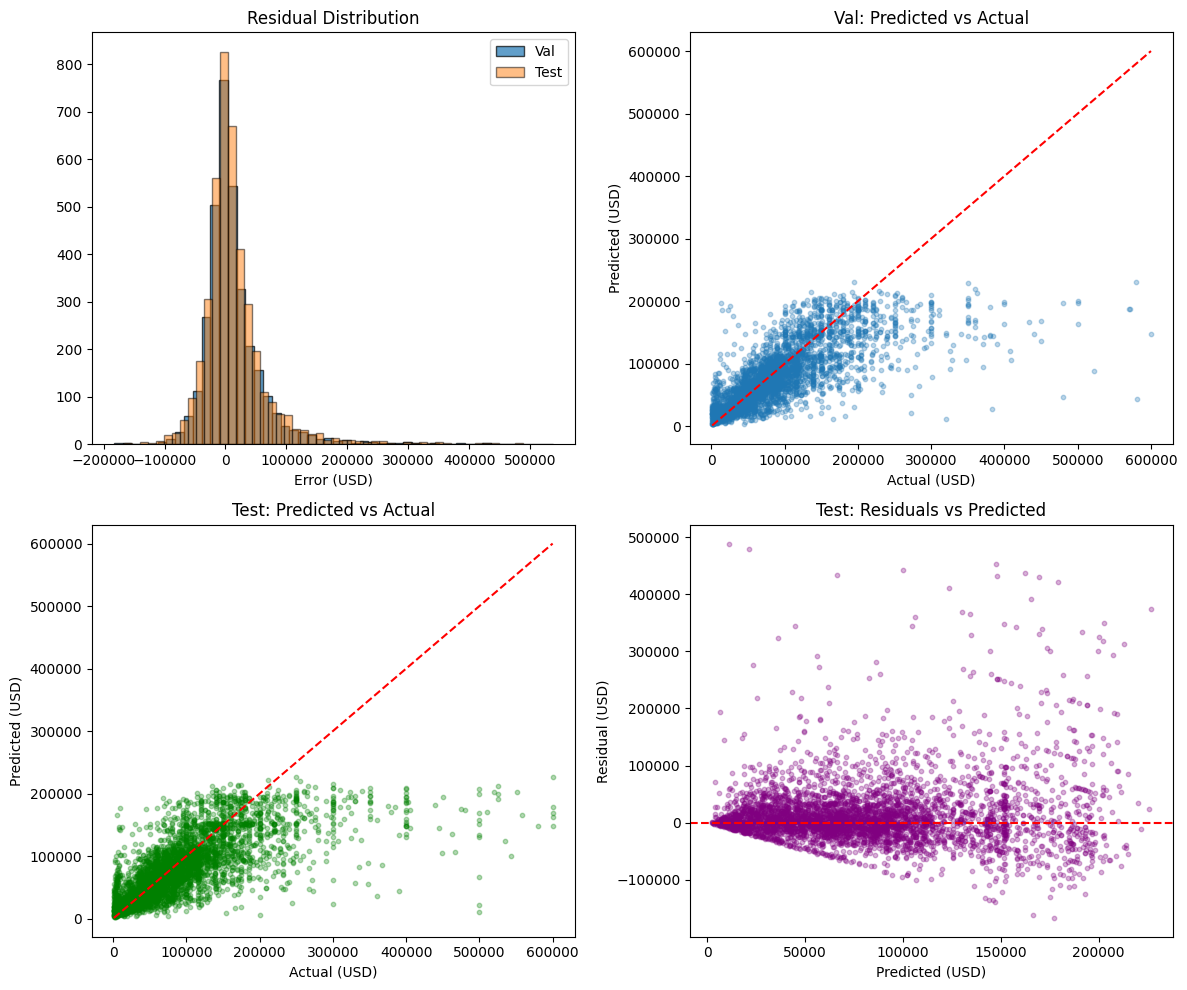

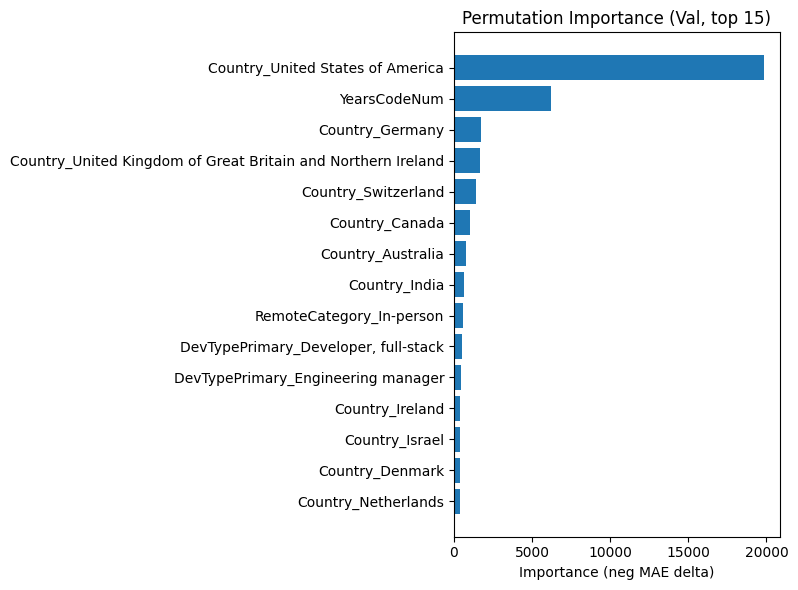

In [57]:
# Diagnostics: residuals, prediction fit, permutation importance

# Reuse existing predictions
val_pred = best_model.predict(X_val)
test_pred = best_model.predict(X_test)

# Residuals
val_resid = y_val - val_pred
test_resid = y_test - test_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residual hist
axes[0, 0].hist(val_resid, bins=50, alpha=0.7, label="Val", edgecolor="black")
axes[0, 0].hist(test_resid, bins=50, alpha=0.5, label="Test", edgecolor="black")
axes[0, 0].set_title("Residual Distribution")
axes[0, 0].set_xlabel("Error (USD)")
axes[0, 0].legend()

# Pred vs actual (val)
axes[0, 1].scatter(y_val, val_pred, alpha=0.3, s=10, label="Val")
axes[0, 1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[0, 1].set_title("Val: Predicted vs Actual")
axes[0, 1].set_xlabel("Actual (USD)")
axes[0, 1].set_ylabel("Predicted (USD)")

# Pred vs actual (test)
axes[1, 0].scatter(y_test, test_pred, alpha=0.3, s=10, label="Test", color="green")
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1, 0].set_title("Test: Predicted vs Actual")
axes[1, 0].set_xlabel("Actual (USD)")
axes[1, 0].set_ylabel("Predicted (USD)")

# Residuals vs predicted (test)
axes[1, 1].scatter(test_pred, test_resid, alpha=0.3, s=10, color="purple")
axes[1, 1].axhline(0, color='r', linestyle='--')
axes[1, 1].set_title("Test: Residuals vs Predicted")
axes[1, 1].set_xlabel("Predicted (USD)")
axes[1, 1].set_ylabel("Residual (USD)")

plt.tight_layout()
plt.show()

# Permutation importance (top 15 features)
perm = permutation_importance(
    best_model, X_val, y_val,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'
)
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Val, top 15)")
plt.xlabel("Importance (neg MAE delta)")
plt.tight_layout()
plt.show()



Overall (test) metrics on errors computed from predictions_best:
MAE        34605.393584
MedAE      19970.096624
MAPE          78.036188
Log-MAE        0.464134
dtype: float64

By salary band (USD):


/var/folders/97/qhn67ff95n3brkkxszz9k2w40000gp/T/ipykernel_75222/1568543975.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eval_df.groupby("salary_band")


,salary_band,count,mae,medae,mape,log_mae
0,0-50k,1196,18017.830355,11754.952330,197.806961,0.709753
1,50-100k,1464,21852.447973,16783.419005,29.657302,0.318477
2,100-150k,820,31384.588122,25740.028963,25.492700,0.308812
3,150-250k,538,59896.330303,53760.196333,30.810119,0.426284
4,250-600k,164,202554.018699,180655.695562,54.097960,0.873954


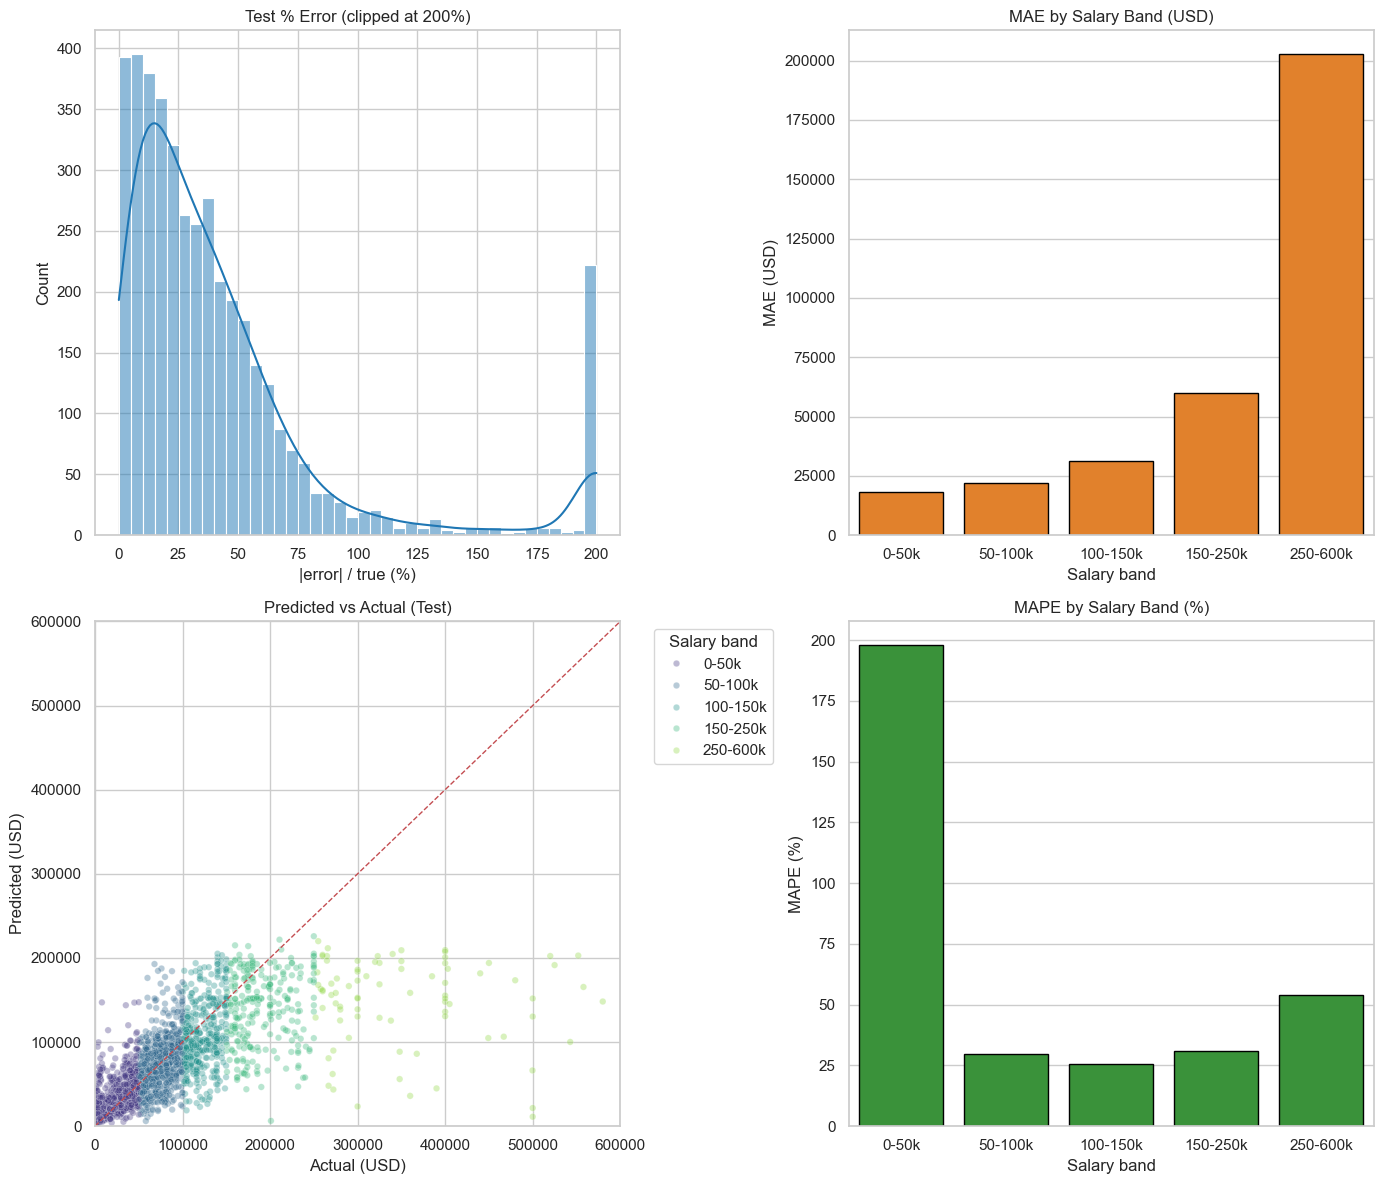

/var/folders/97/qhn67ff95n3brkkxszz9k2w40000gp/T/ipykernel_75222/1568543975.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, x="salary_band", y="abs_error", palette="pastel")


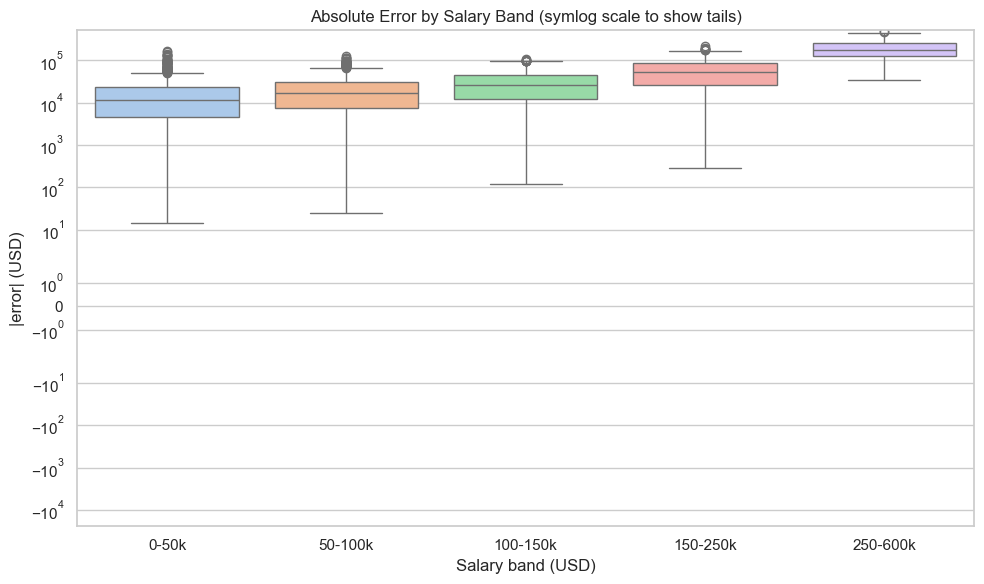

In [58]:
# Extended evaluation: relative errors, salary bands, and richer visuals
sns.set_theme(style="whitegrid")

# Reuse test predictions from above (test_pred, y_test)
eval_df = pd.DataFrame({
    "salary_true": y_test,
    "salary_pred": test_pred,
})
eval_df["abs_error"] = (eval_df["salary_true"] - eval_df["salary_pred"]).abs()
eval_df["pct_error"] = eval_df["abs_error"] / eval_df["salary_true"].clip(lower=1e-6) * 100

eval_df["log_true"] = np.log1p(eval_df["salary_true"])
eval_df["log_pred"] = np.log1p(eval_df["salary_pred"])
eval_df["abs_log_error"] = (eval_df["log_true"] - eval_df["log_pred"]).abs()

# Salary bands for segmented metrics
bands = [0, 50_000, 100_000, 150_000, 250_000, 600_000]
band_labels = ["0-50k", "50-100k", "100-150k", "150-250k", "250-600k"]
eval_df["salary_band"] = pd.cut(eval_df["salary_true"], bins=bands, labels=band_labels, include_lowest=True)

# Band-level summary
band_metrics = (
    eval_df.groupby("salary_band")
    .agg(
        count=("salary_true", "size"),
        mae=("abs_error", "mean"),
        medae=("abs_error", "median"),
        mape=("pct_error", "mean"),
        log_mae=("abs_log_error", "mean"),
    )
    .reset_index()
)

print("Overall (test) metrics on errors computed from predictions_best:")
overall_metrics = {
    "MAE": eval_df["abs_error"].mean(),
    "MedAE": eval_df["abs_error"].median(),
    "MAPE": eval_df["pct_error"].mean(),
    "Log-MAE": eval_df["abs_log_error"].mean(),
}
print(pd.Series(overall_metrics))
print("\nBy salary band (USD):")
display(band_metrics)

# --- Visuals ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1) Absolute percentage error distribution (clipped for readability)
clipped_pct = eval_df["pct_error"].clip(upper=200)  # cap at 200% to show bulk
sns.histplot(clipped_pct, bins=40, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Test % Error (clipped at 200%)")
axes[0, 0].set_xlabel("|error| / true (%)")

# 2) MAE / MAPE by salary band
sns.barplot(
    data=band_metrics,
    x="salary_band",
    y="mae",
    ax=axes[0, 1],
    color="#ff7f0e",
    edgecolor="black",
)
axes[0, 1].set_title("MAE by Salary Band (USD)")
axes[0, 1].set_xlabel("Salary band")
axes[0, 1].set_ylabel("MAE (USD)")

sns.barplot(
    data=band_metrics,
    x="salary_band",
    y="mape",
    ax=axes[1, 1],
    color="#2ca02c",
    edgecolor="black",
)
axes[1, 1].set_title("MAPE by Salary Band (%)")
axes[1, 1].set_xlabel("Salary band")
axes[1, 1].set_ylabel("MAPE (%)")

# 3) Predicted vs actual with band hue
sns.scatterplot(
    data=eval_df.sample(min(len(eval_df), 2000), random_state=RANDOM_STATE),
    x="salary_true",
    y="salary_pred",
    hue="salary_band",
    palette="viridis",
    alpha=0.35,
    s=22,
    ax=axes[1, 0],
)
max_val = max(eval_df["salary_true"].max(), eval_df["salary_pred"].max())
axes[1, 0].plot([0, max_val], [0, max_val], "r--", linewidth=1)
axes[1, 0].set_title("Predicted vs Actual (Test)")
axes[1, 0].set_xlabel("Actual (USD)")
axes[1, 0].set_ylabel("Predicted (USD)")
axes[1, 0].set_xlim(0, max_val)
axes[1, 0].set_ylim(0, max_val)
axes[1, 0].legend(title="Salary band", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Additional boxplot to see error spread per band
plt.figure(figsize=(10, 6))
sns.boxplot(data=eval_df, x="salary_band", y="abs_error", palette="pastel")
plt.yscale("symlog")
plt.title("Absolute Error by Salary Band (symlog scale to show tails)")
plt.xlabel("Salary band (USD)")
plt.ylabel("|error| (USD)")
plt.tight_layout()
plt.show()

